# IMPORTING ALL THE NEEDED LIBRARIES


In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

#Data splitting 
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, GridSearchCV

# Preprocessing 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize

#Classification algorithms
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from pandas.plotting import scatter_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC 
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier


#EVALUATION MATRIX
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score
)
# OTHER UTILITIES


print("Libraries imported successfully.")




Libraries imported successfully.


# Importing data and creating a dataframe


In [162]:

df = pd.read_csv("gbv.csv")

print(df.head())  # shows first 5 rows


  Province;Station;Latitude;Longitude;Risk;2022;2023;2024;2025;2026;TOTAL
0  Free State;Park Road;-29.11994;26.21159;High;1...                     
1  Gauteng;Midrand;-25.997;28.128;High;1420;1765;...                     
2  Gauteng;Honeydew;-26.0732;27.9201;High;2149;17...                     
3  Gauteng;Roodepoort;-26.17733;27.97173;High;136...                     
4  Gauteng;JHB Central;-26.20676;28.03141;High;20...                     


In [163]:

# Load GBV dataset (semicolon-separated)
gbv = pd.read_csv("gbv.csv", sep=";")

# Create DataFrame with selected columns
df = pd.DataFrame(
    gbv[["Province", "Station", "Latitude", "Longitude", "Risk", "2022", "2023", "2024", "2025", "2026", "TOTAL"]]
)

# Map risk levels to numeric codes (like iris target)
risk_map = {"High": 2, "Med-high": 1}
df["risk_code"] = df["Risk"].map(risk_map)

# Add descriptive mapping back (like species names in iris)
df["risk_label"] = df["risk_code"].map({2: "High Risk", 1: "Medium-High Risk"})

# Preview
print(df.head())


     Province      Station   Latitude  Longitude  Risk  2022  2023  2024  \
0  Free State    Park Road  -29.11994   26.21159  High  1903  1982  1933   
1     Gauteng      Midrand    -25.997   28.12800  High  1420  1765  1764   
2     Gauteng     Honeydew   -26.0732   27.92010  High  2149  1717  1838   
3     Gauteng   Roodepoort  -26.17733   27.97173  High  1367  1806  1858   
4     Gauteng  JHB Central  -26.20676   28.03141  High  2021  2231  1954   

   2025  2026  TOTAL  risk_code risk_label  
0  1806  1682   9306        2.0  High Risk  
1  1736  1679   8364        2.0  High Risk  
2  1644  1665   9013        2.0  High Risk  
3  1603  1558   8192        2.0  High Risk  
4  1556  1505   9267        2.0  High Risk  


In [164]:
print("Dataset shape")
print(df.shape)


Dataset shape
(35, 13)


In [121]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['Province', 'Station', 'Latitude', 'Longitude', 'Risk', '2022', '2023', '2024', '2025', '2026', 'TOTAL', 'risk_code', 'risk_label']


In [165]:
print("\nDataset information:")
df.info()



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Province    35 non-null     str    
 1   Station     35 non-null     str    
 2   Latitude    30 non-null     str    
 3   Longitude   30 non-null     float64
 4   Risk        30 non-null     str    
 5   2022        35 non-null     int64  
 6   2023        35 non-null     int64  
 7   2024        35 non-null     int64  
 8   2025        35 non-null     int64  
 9   2026        35 non-null     int64  
 10  TOTAL       35 non-null     int64  
 11  risk_code   30 non-null     float64
 12  risk_label  30 non-null     str    
dtypes: float64(2), int64(6), str(5)
memory usage: 5.1 KB


In [30]:
#data describtion

df.describe()

,Longitude,2022,2023,2024,2025,2026,TOTAL,risk_code
count,30.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,30.000000
mean,26.971149,4000.714286,4307.800000,4411.628571,4152.057143,3938.571429,20810.771429,1.766667
std,4.812232,8504.040125,9137.908233,9334.065923,8776.839733,8327.159293,44073.724121,0.430183
min,18.423100,1018.000000,1178.000000,1399.000000,1236.000000,1276.000000,6210.000000,1.000000
25%,26.470805,1373.000000,1456.500000,1490.500000,1438.500000,1350.500000,7232.500000,2.000000
50%,28.210880,1494.000000,1601.000000,1640.000000,1564.000000,1505.000000,7892.000000,2.000000
75%,30.882038,1997.000000,2100.000000,1966.500000,1882.500000,1737.500000,9308.000000,2.000000
max,31.886230,48504.000000,52197.000000,53360.000000,50166.000000,47549.000000,251776.000000,2.000000


Risk
High        23
Med-high     7
Name: count, dtype: int64


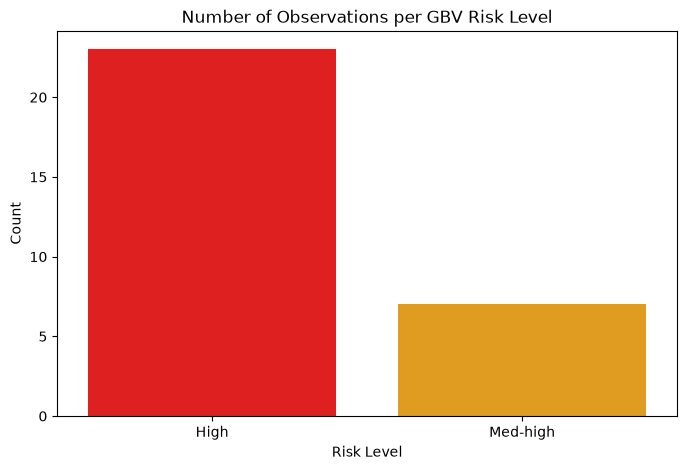

In [166]:


# Plot class distribution of Risk levels
print(df["Risk"].value_counts())

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Risk",
    hue="Risk",
    palette={
        "High": "red",
        "Med-high": "orange"
    },
    legend=False
)

plt.title("Number of Observations per GBV Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()


# Histogram displaying the provinces an sexual cases


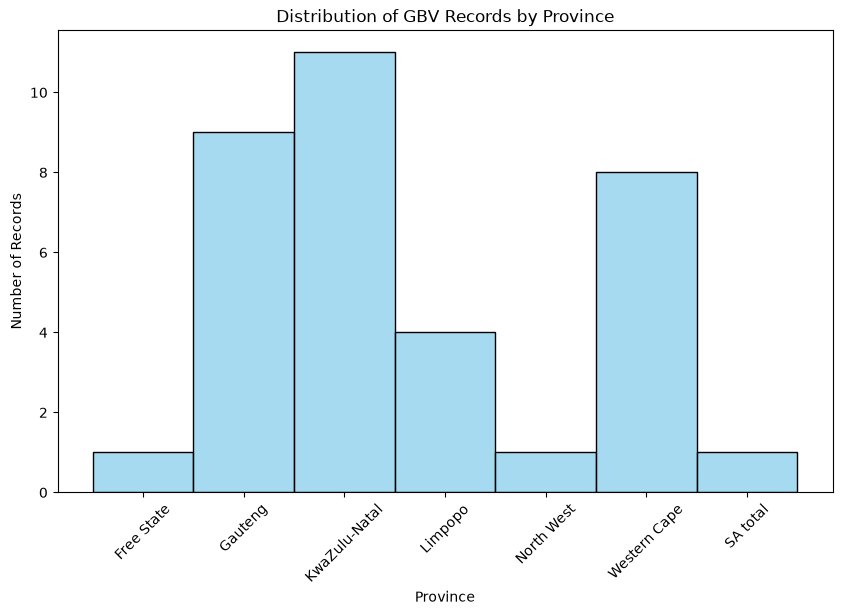

In [167]:

# Plot histogram of provinces
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Province",
    stat="count",
    bins=len(df["Province"].unique()),
    color="skyblue"
)

plt.title("Distribution of GBV Records by Province")
plt.xlabel("Province")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()


# HISTOGRAM GRAPH OF PROVINCES VS TOTAL NUMBER OF CASES

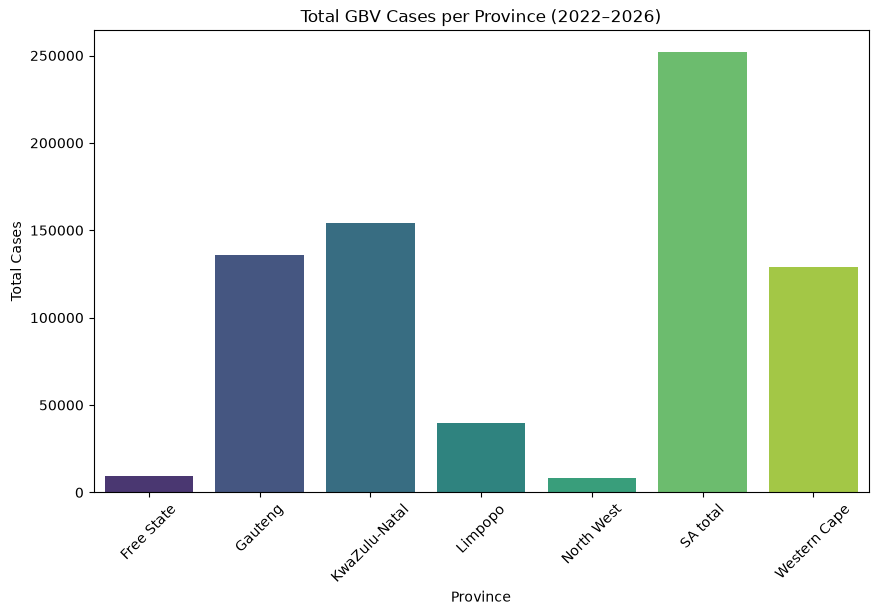

In [168]:

# Group by province and sum total cases
province_totals = gbv.groupby("Province")["TOTAL"].sum().reset_index()

# Plot totals per province
plt.figure(figsize=(10,6))

sns.barplot(
    data=province_totals,
    x="Province",
    y="TOTAL",
    hue="Province",          # assign hue to match palette
    palette="viridis",
    legend=False             # hide duplicate legend
)

plt.title("Total GBV Cases per Province (2022–2026)")
plt.xlabel("Province")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)
plt.show()


# Scatter PLOT OF DISTRICT LOCATION WITH HIGH GBV CASES 

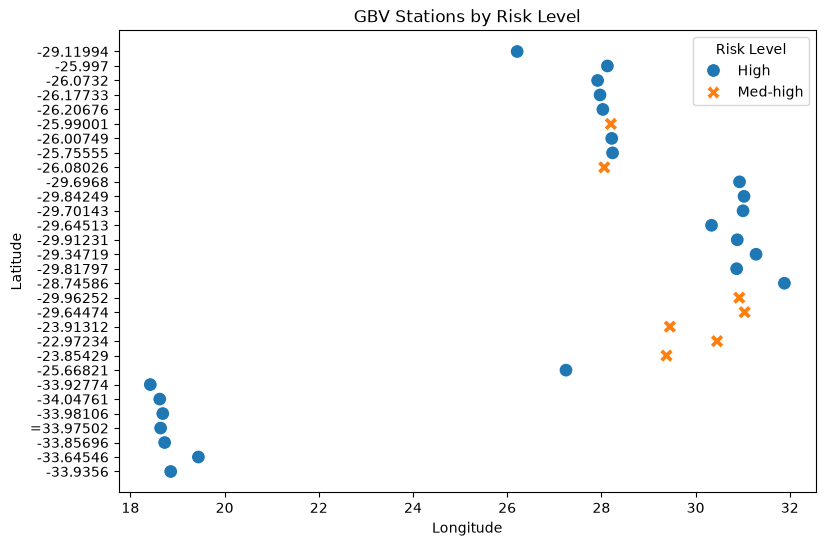

In [169]:

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Risk",        # color by risk level
    style="Risk",      # marker style by risk level
    s=100
)

plt.title("GBV Stations by Risk Level")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Risk Level")
plt.show()


# MULTIPLE SCATTER PLOTS

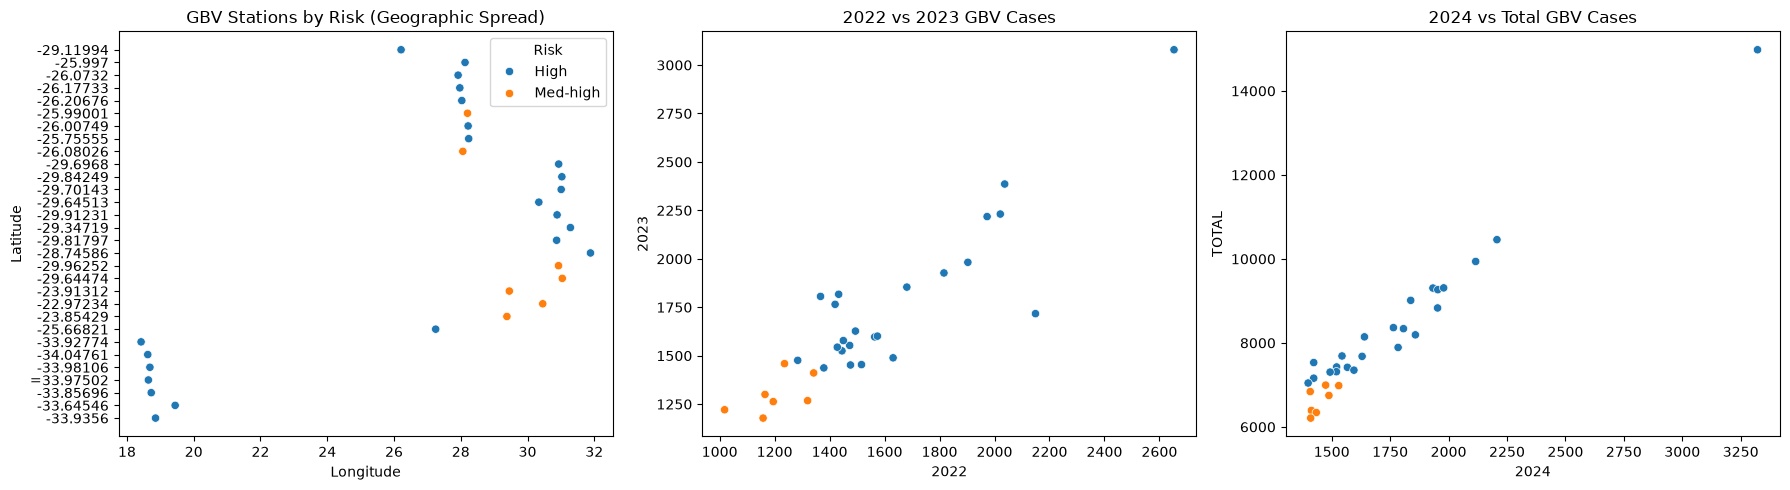

In [170]:

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot 1: Longitude vs Latitude
sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="Risk",
    ax=axes[0]
)
axes[0].set_title("GBV Stations by Risk (Geographic Spread)")

# Scatter plot 2: 2022 vs 2023 cases
sns.scatterplot(
    data=df,
    x="2022",
    y="2023",
    hue="Risk",
    ax=axes[1],
    legend=False
)
axes[1].set_title("2022 vs 2023 GBV Cases")

# Scatter plot 3: 2024 vs TOTAL cases
sns.scatterplot(
    data=df,
    x="2024",
    y="TOTAL",
    hue="Risk",
    ax=axes[2],
    legend=False
)
axes[2].set_title("2024 vs Total GBV Cases")

plt.tight_layout()
plt.show()


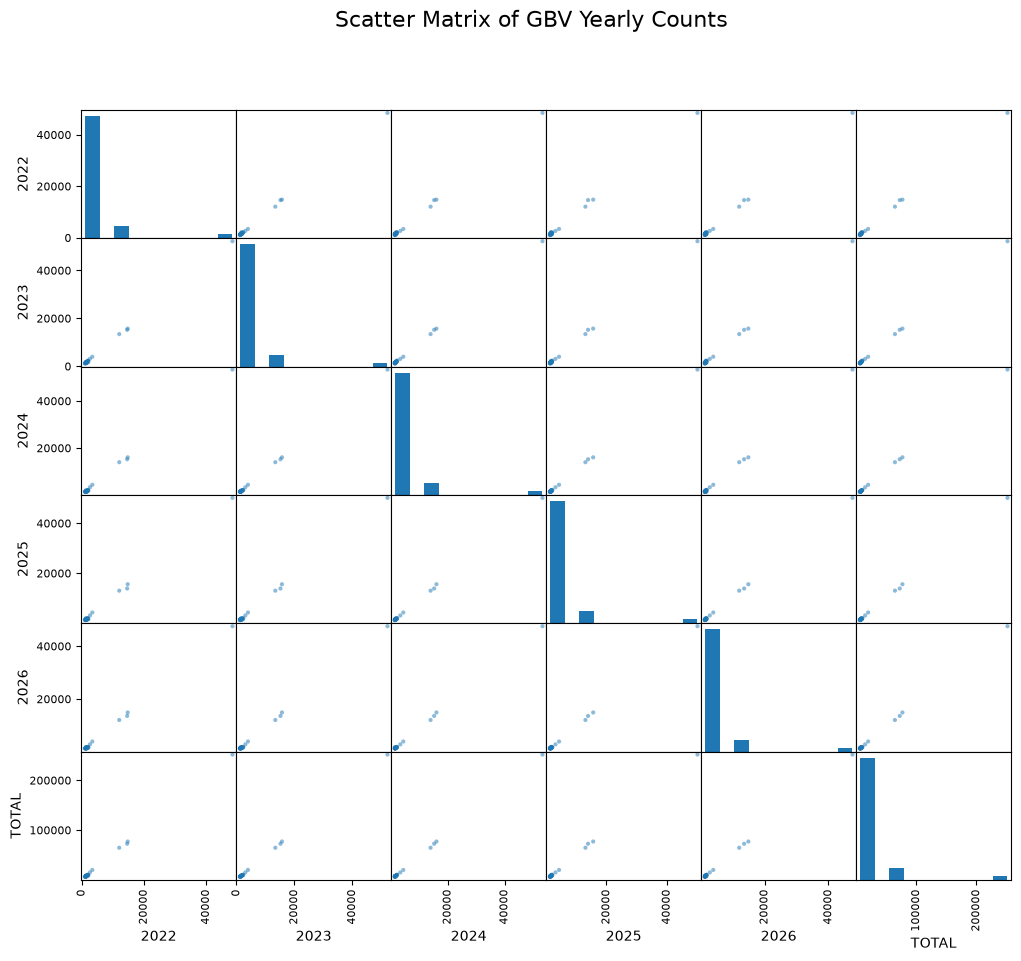

In [171]:

# Select numeric columns (yearly counts + TOTAL)
numeric_cols = ["2022", "2023", "2024", "2025", "2026", "TOTAL"]

# Create scatter matrix
scatter_matrix(
    df[numeric_cols],
    figsize=(12, 10),
    diagonal="hist"
)

plt.suptitle("Scatter Matrix of GBV Yearly Counts", fontsize=16)
plt.show()


# SCATTER PLOT MATRIX FOR DISTRICT LOCATION WITH HIGH GBV CASES

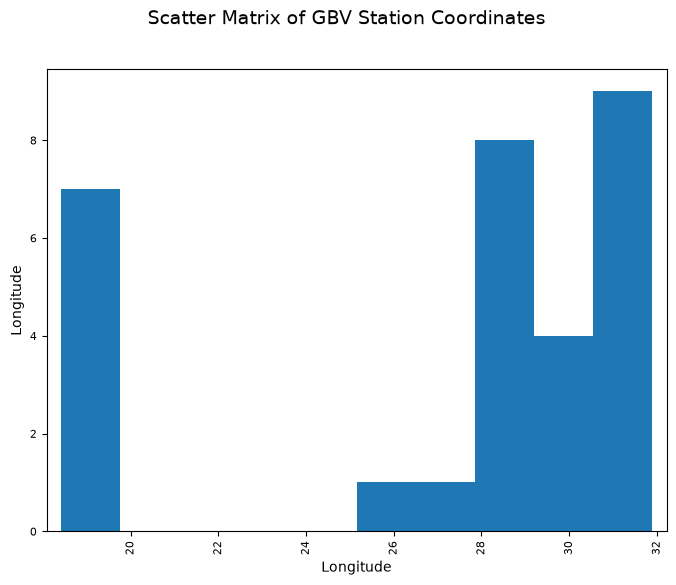

In [172]:

# Select latitude and longitude columns
geo_cols = ["Latitude", "Longitude"]

# Create scatter matrix
scatter_matrix(
    gbv[geo_cols],
    figsize=(8, 6),
    diagonal="hist"
)

plt.suptitle("Scatter Matrix of GBV Station Coordinates", fontsize=14)
plt.show()


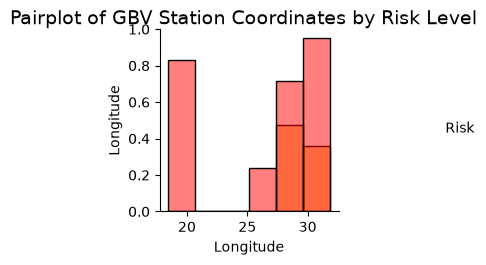

In [173]:

# Select latitude and longitude plus risk
geo_data = df[["Latitude", "Longitude", "Risk"]]

# Create pairplot with hue for risk
sns.pairplot(
    geo_data,
    hue="Risk",
    diag_kind="hist",
    palette={"High": "red", "Med-high": "orange"}
)

plt.suptitle("Pairplot of GBV Station Coordinates by Risk Level", y=1.02, fontsize=14)
plt.show()


# MULTIPLE FEATURES MATRIX 

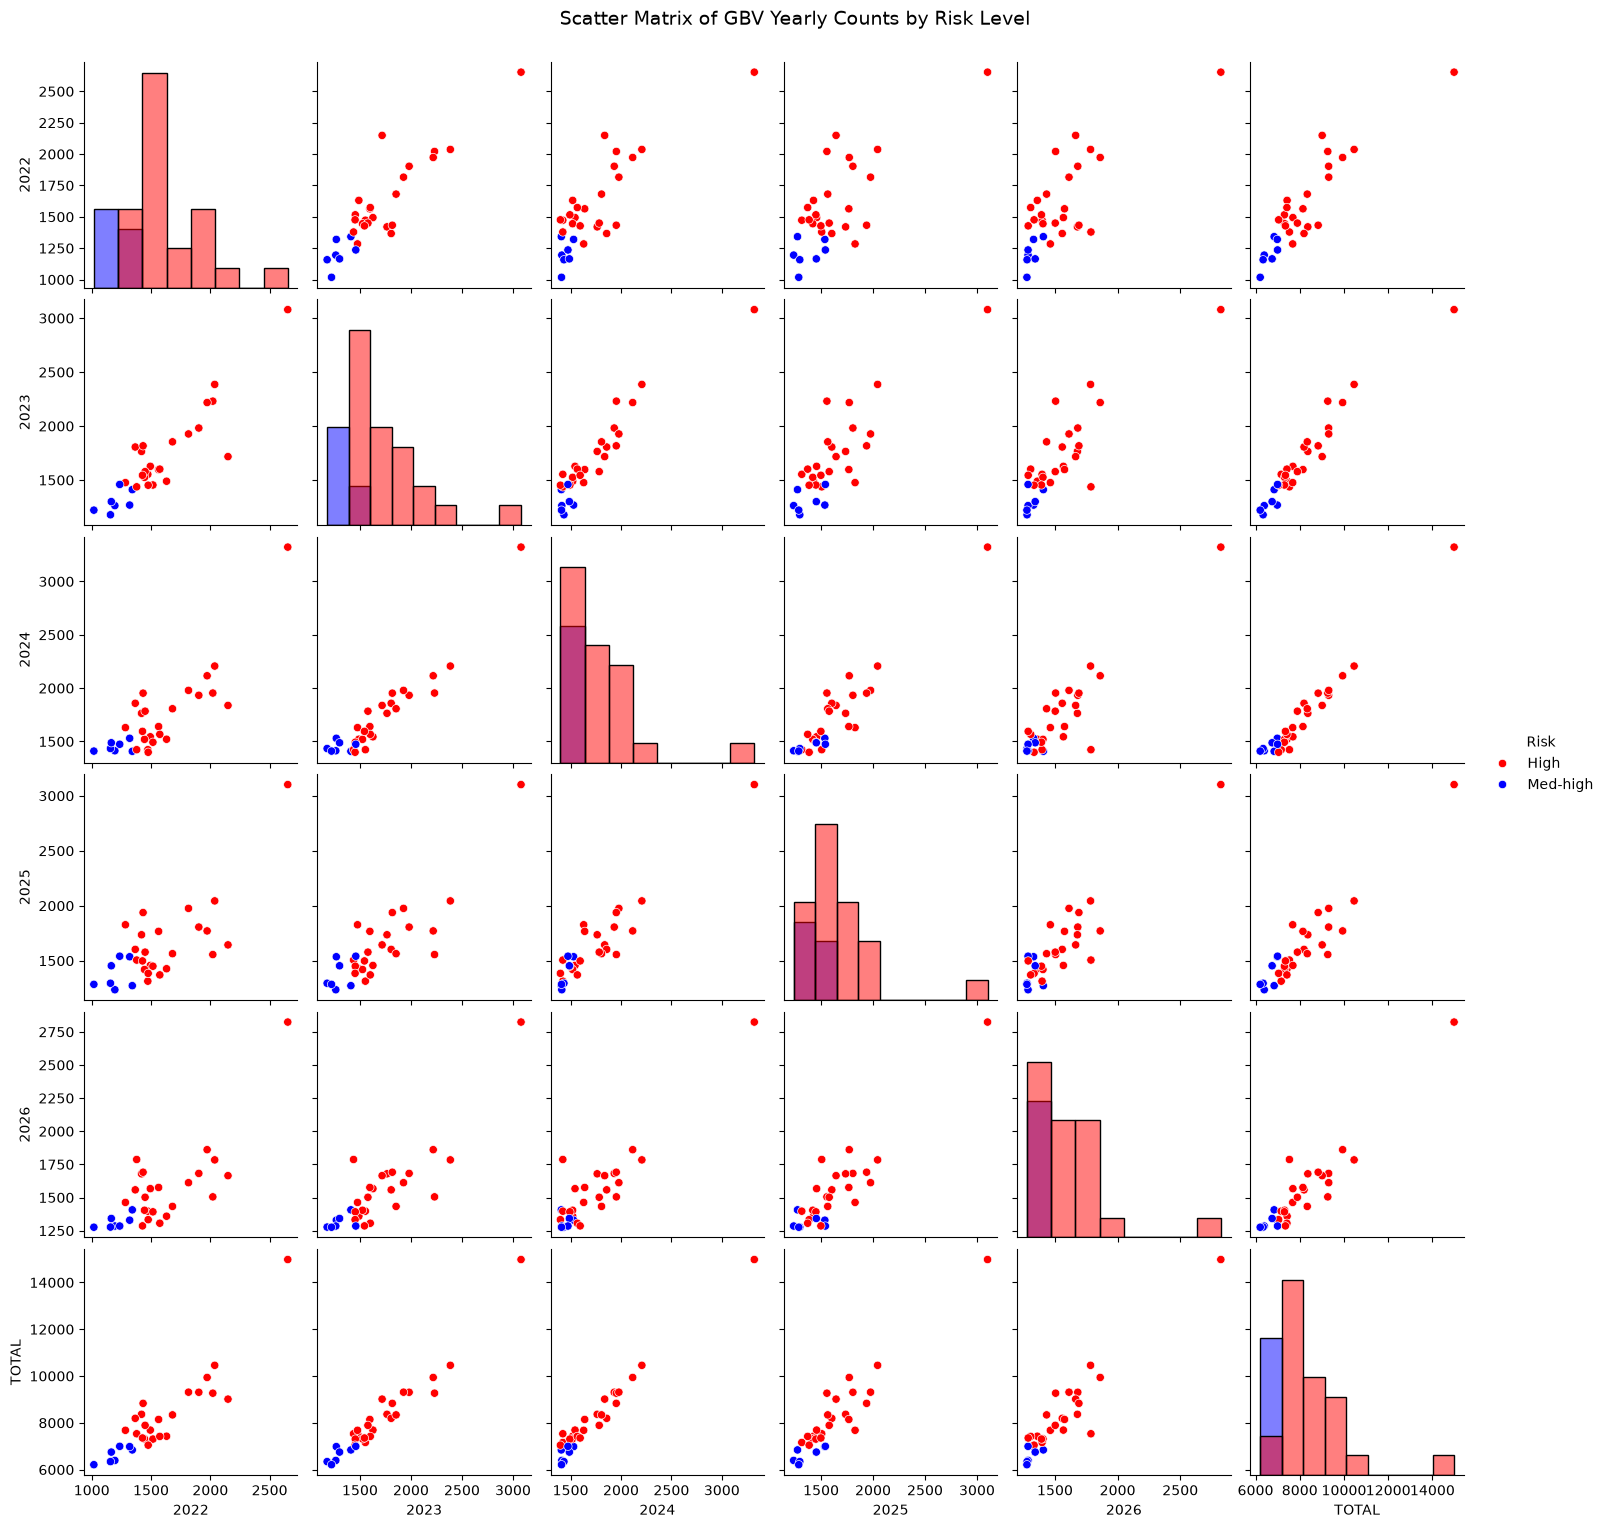

In [174]:

# Select numeric columns + Risk
gbv_data = gbv[["2022", "2023", "2024", "2025", "2026", "TOTAL", "Risk"]]

# Create pairplot with custom colors
sns.pairplot(
    gbv_data,
    hue="Risk",
    diag_kind="hist",
    palette={"High": "red", "Med-high": "blue"}
)

plt.suptitle(
    "Scatter Matrix of GBV Yearly Counts by Risk Level",
    y=1.02,
    fontsize=14
)
plt.show()


# MULTIPLE FEATURES MATRIX("LATITUDE","LONGITUDE"AND "RISK LEVEL"

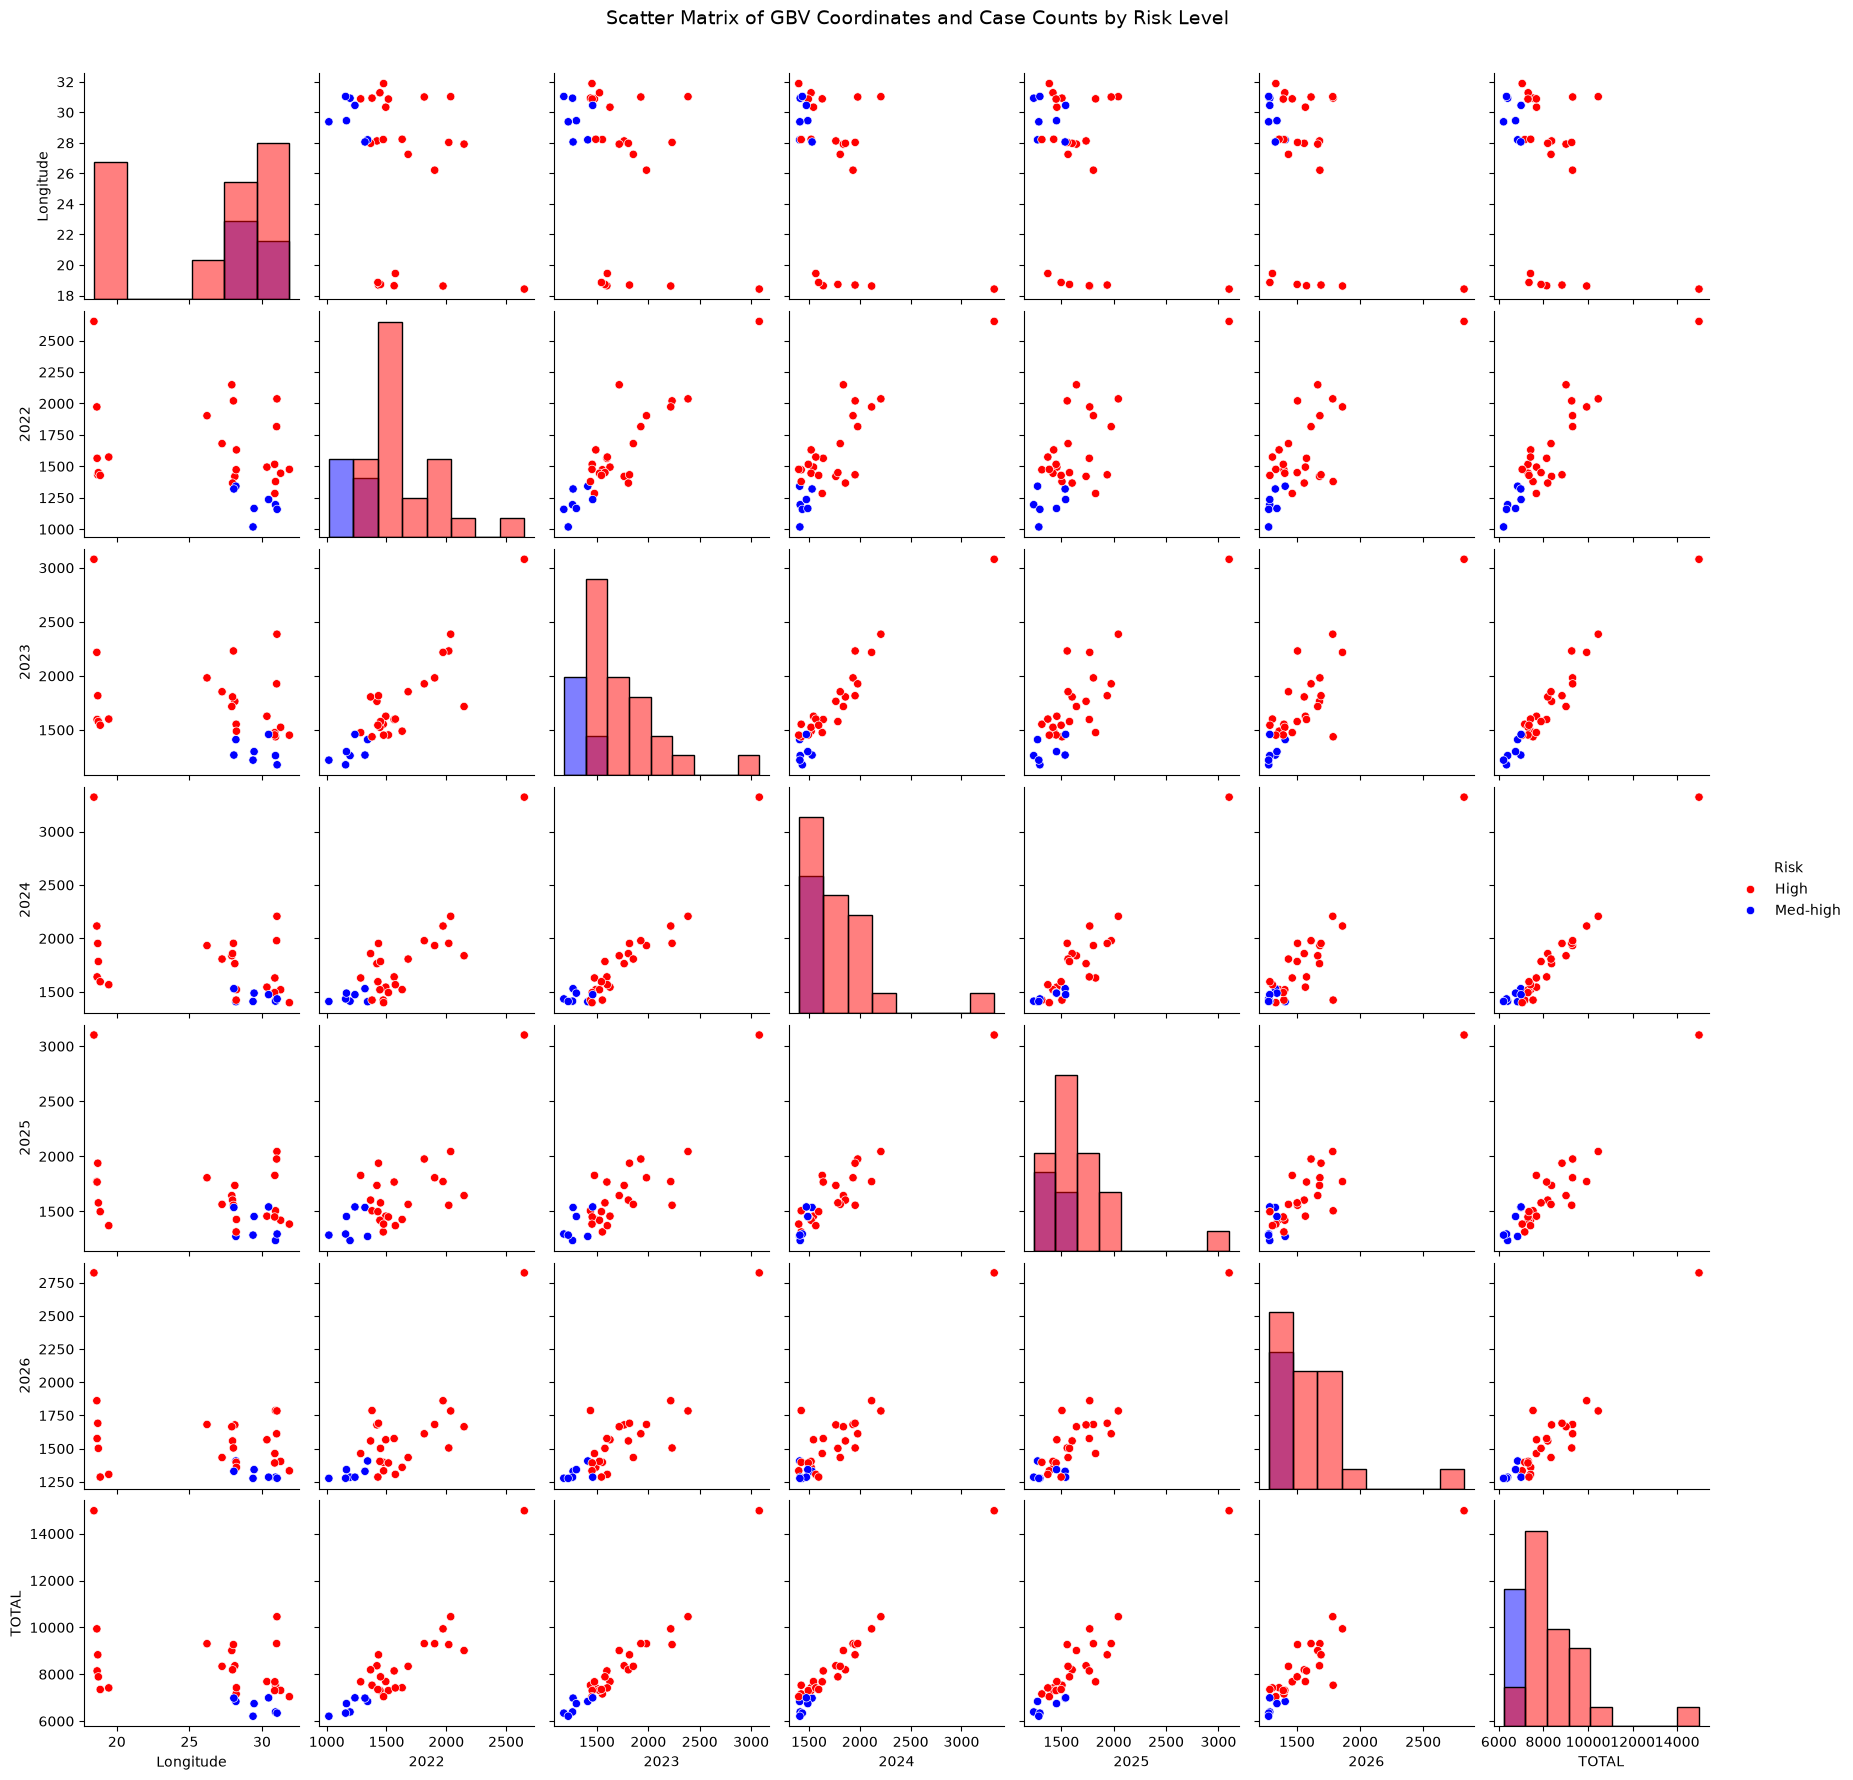

In [175]:


# Select latitude, longitude, totals, and yearly counts + risk
gbv_data = gbv[["Latitude", "Longitude", "2022", "2023", "2024", "2025", "2026", "TOTAL", "Risk"]]

# Create pairplot with custom colors
sns.pairplot(
    gbv_data,
    hue="Risk",
    diag_kind="hist",
    palette={"High": "red", "Med-high": "blue"}
)

plt.suptitle(
    "Scatter Matrix of GBV Coordinates and Case Counts by Risk Level",
    y=1.02,
    fontsize=14
)
plt.show()


C:\Users\TechMarkit\AppData\Local\Temp\ipykernel_20284\3874305701.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


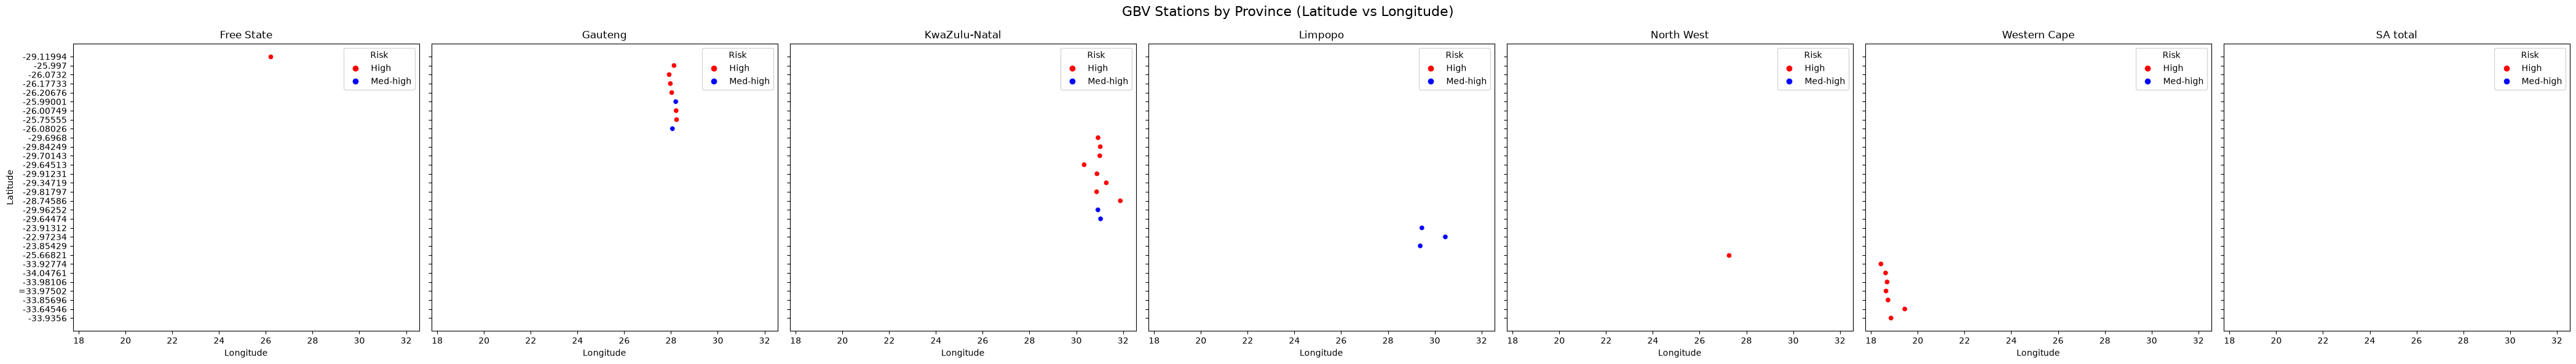

In [131]:
from matplotlib.lines import Line2D

provinces = gbv["Province"].unique()
fig, axes = plt.subplots(
    1, len(provinces),
    figsize=(6 * len(provinces), 6),
    sharex=True, sharey=True
)

if len(provinces) == 1:
    axes = [axes]

for ax, province in zip(axes, provinces):
    sns.scatterplot(
        data=gbv[gbv["Province"] == province],
        x="Longitude",
        y="Latitude",
        hue="Risk",
        palette={"High": "red", "Med-high": "blue"},
        hue_order=["High", "Med-high"],   # force both categories
        ax=ax
    )
    ax.set_title(province)

    # Fixed legend (always shows both categories)
    handles = [
        Line2D([0], [0], marker='o', color='w', label='High',
               markerfacecolor='red', markersize=8),
        Line2D([0], [0], marker='o', color='w', label='Med-high',
               markerfacecolor='blue', markersize=8)
    ]
    ax.legend(handles=handles, title="Risk", loc="best")

plt.suptitle("GBV Stations by Province (Latitude vs Longitude)", fontsize=16)
plt.tight_layout()
plt.show()


# HISTOGRAM OF GBV FEATURES

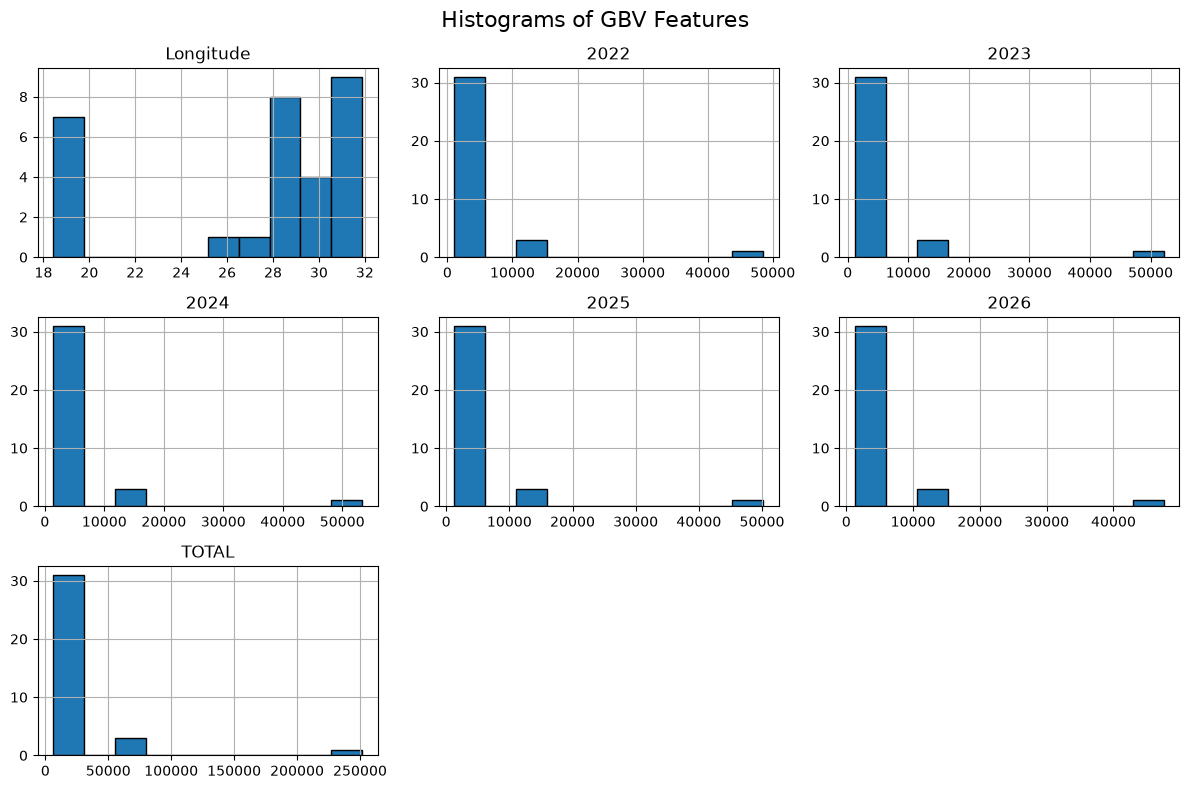

In [176]:
# HISTOGRAMS OF THE FEATURES OF GBV DATASET

# Select numeric columns only (histograms make sense for numeric data)
features = gbv.select_dtypes(include="number").columns

# Plot histograms for each numeric feature
gbv[features].hist(
    figsize=(12, 8),
    bins=10,
    edgecolor="black"
)

plt.suptitle(
    "Histograms of GBV Features",
    fontsize=16
)
plt.tight_layout()
plt.show()


# GBV CASES BY PROVINCES PER YEAR

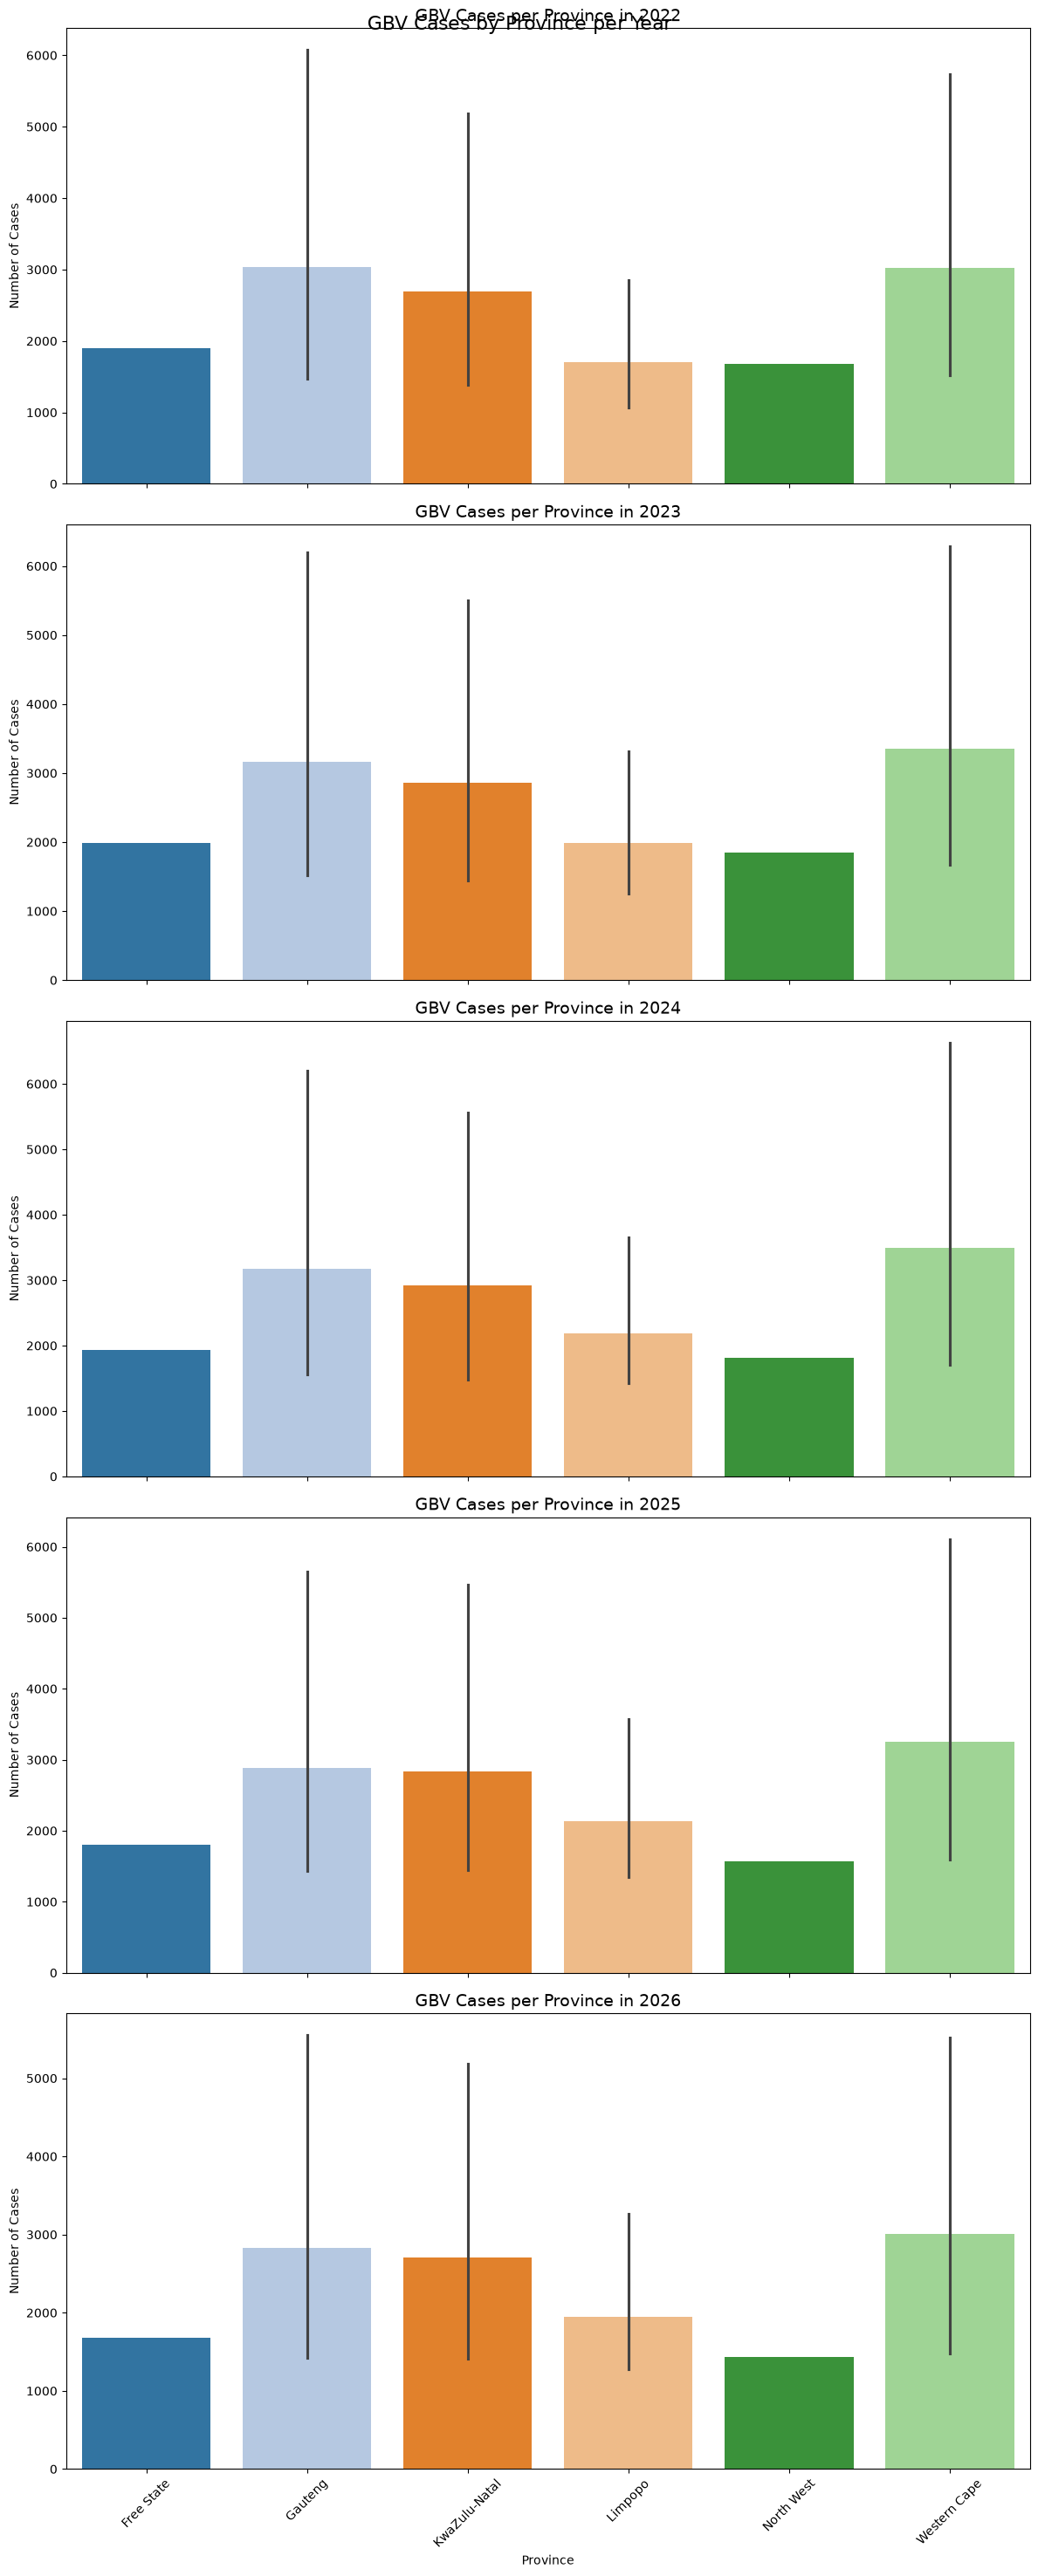

In [177]:

# Exclude the SA Total row
gbv = gbv[gbv["Province"].str.strip().str.lower() != "sa total"]

# Reshape from wide to long format
gbv_long = gbv.melt(
    id_vars=["Province"], 
    value_vars=["2022","2023","2024","2025","2026"], 
    var_name="Year", 
    value_name="Cases"
)

# Get unique years
years = gbv_long["Year"].unique()

# Create subplots (one per year)
fig, axes = plt.subplots(len(years), 1, figsize=(12, 6 * len(years)), sharex=True)

if len(years) == 1:
    axes = [axes]

# Loop through years and plot bar chart with province colors
for ax, year in zip(axes, years):
    sns.barplot(
        data=gbv_long[gbv_long["Year"] == year],
        x="Province",
        y="Cases",
        hue="Province",        # different colors per province
        dodge=False,           # one bar per province
        palette="tab20",       # colorful palette
        ax=ax
    )
    ax.set_title(f"GBV Cases per Province in {year}", fontsize=14)
    ax.set_xlabel("Province")
    ax.set_ylabel("Number of Cases")
    ax.tick_params(axis="x", rotation=45)

    # Safely remove legend if it exists
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.suptitle("GBV Cases by Province per Year", fontsize=16)
plt.tight_layout()
plt.show()


# CLASS STRICTIFIED HISTOGRAMS

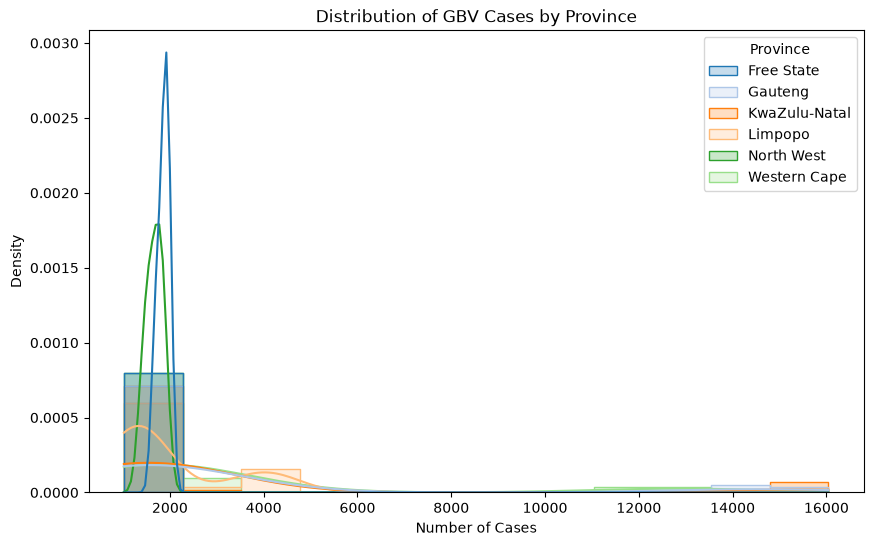

In [178]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=gbv_long,          # reshaped GBV dataset
    x="Cases",              # numeric values
    hue="Province",         # stratify by province
    bins=12,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette="tab20"         # distinct colors for provinces
)

plt.title("Distribution of GBV Cases by Province")
plt.xlabel("Number of Cases")
plt.ylabel("Density")
plt.show()


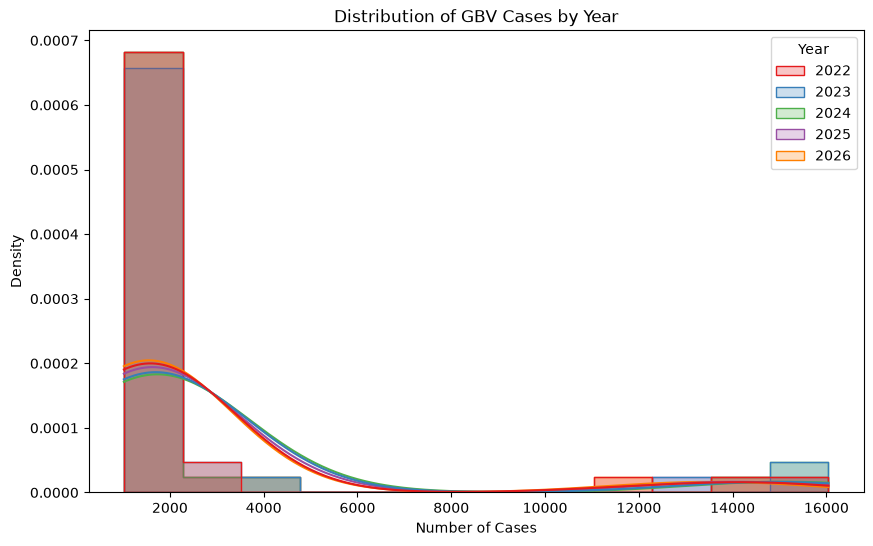

In [179]:

# Exclude the SA Total row
gbv = gbv[gbv["Province"].str.strip().str.lower() != "sa total"]

# Reshape from wide to long format
gbv_long = gbv.melt(
    id_vars=["Province"], 
    value_vars=["2022","2023","2024","2025","2026"], 
    var_name="Year", 
    value_name="Cases"
)

# CLASS STRATIFIED HISTOGRAMS (Years)
plt.figure(figsize=(10, 6))

sns.histplot(
    data=gbv_long,
    x="Cases",          # numeric values
    hue="Year",         # stratify by year
    bins=12,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette="Set1"      # distinct colors for years
)

plt.title("Distribution of GBV Cases by Year")
plt.xlabel("Number of Cases")
plt.ylabel("Density")
plt.show()


# QUANTILE PLOTTING

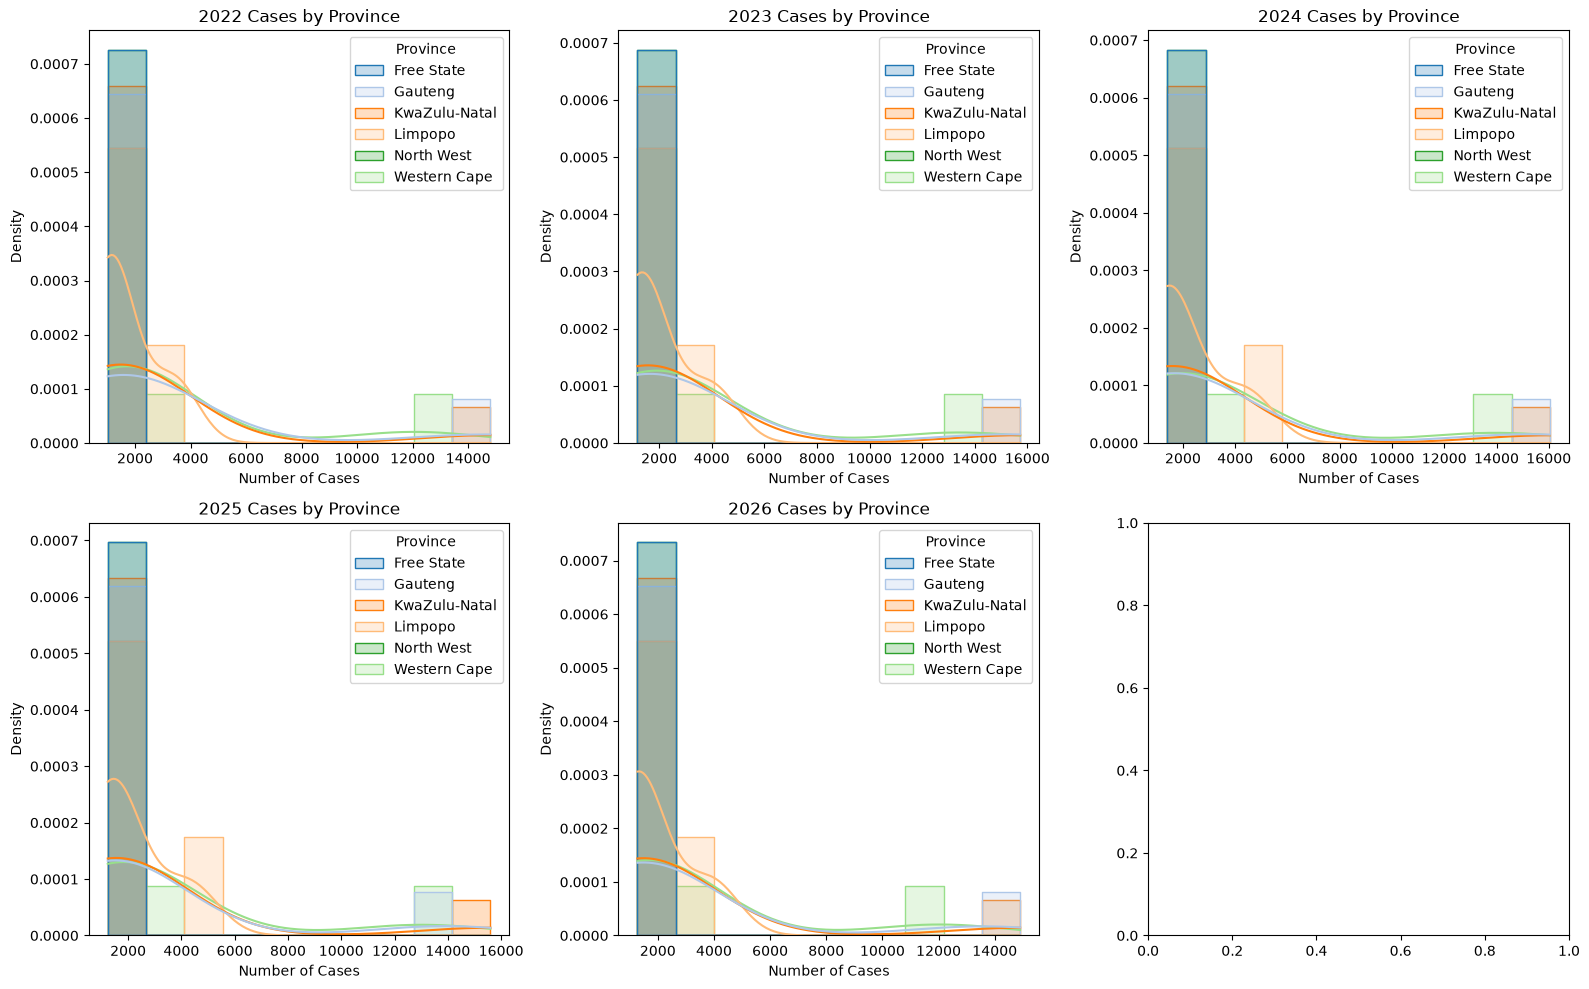

In [180]:

# Select numeric features (the yearly columns)
features = ["2022","2023","2024","2025","2026"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))  # 2x3 grid for 5 years
axes = axes.flatten()

for feature, ax in zip(features, axes):
    sns.histplot(
        data=gbv[gbv["Province"].str.strip().str.lower() != "sa total"],  # exclude SA Total
        x=feature,
        hue="Province",        # stratify by province
        bins=10,
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        palette="tab20",
        ax=ax
    )
    ax.set_title(f"{feature} Cases by Province")
    ax.set_xlabel("Number of Cases")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


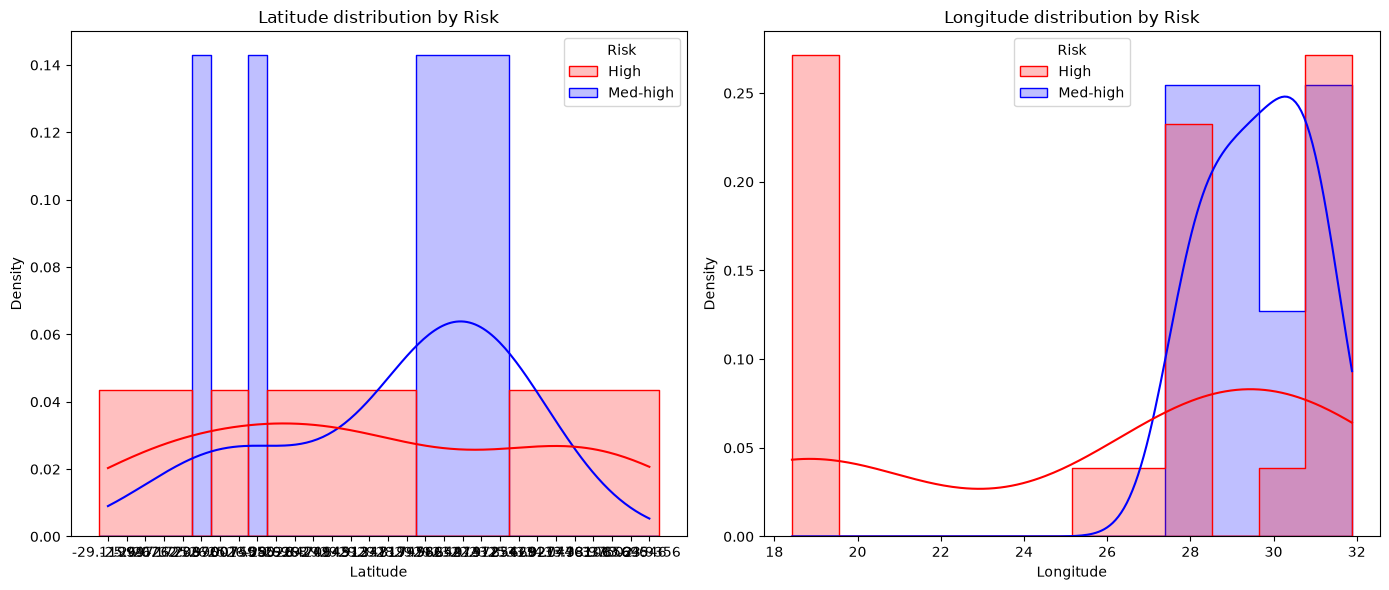

In [181]:

# Exclude SA Total row if present
gbv_geo = gbv[gbv["Province"].str.strip().str.lower() != "sa total"]

# Features to plot
features = ["Latitude", "Longitude"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for feature, ax in zip(features, axes):
    sns.histplot(
        data=gbv_geo,
        x=feature,
        hue="Risk",          # stratify by risk level
        bins=12,
        kde=True,
        element="step",
        stat="density",
        common_norm=False,
        palette={"High": "red", "Med-high": "blue"},
        ax=ax
    )
    ax.set_title(f"{feature} distribution by Risk")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


# QUANTILE PLOTTING FOR MULTIPLE FEATURES

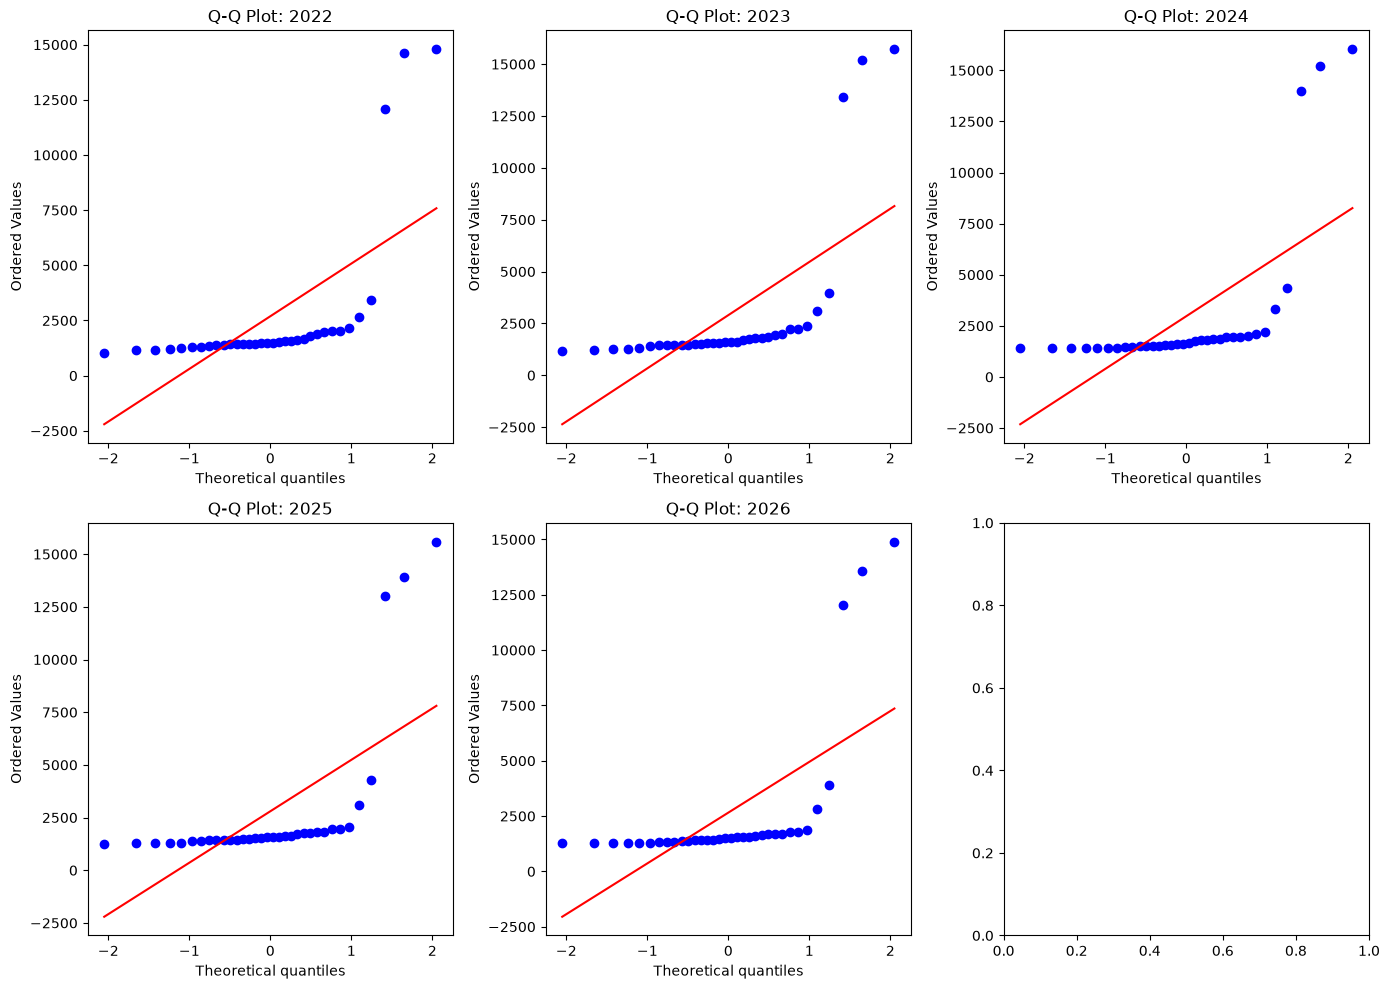

In [182]:
import matplotlib.pyplot as plt


# Exclude SA Total row
gbv_clean = gbv[gbv["Province"].str.strip().str.lower() != "sa total"]

# Select numeric features (the yearly case columns, plus Latitude/Longitude if you want)
features = ["2022","2023","2024","2025","2026"]

# Create subplots grid
fig, axes = plt.subplots(2, 3, figsize=(14, 10))  # 2x3 grid for 5 features
axes = axes.flatten()

# Loop through features and plot Q-Q plots
for feature, ax in zip(features, axes):
    stats.probplot(
        gbv_clean[feature],   # data for that year
        dist="norm",          # compare against normal distribution
        plot=ax
    )
    ax.set_title(f"Q-Q Plot: {feature}")

plt.tight_layout()
plt.show()


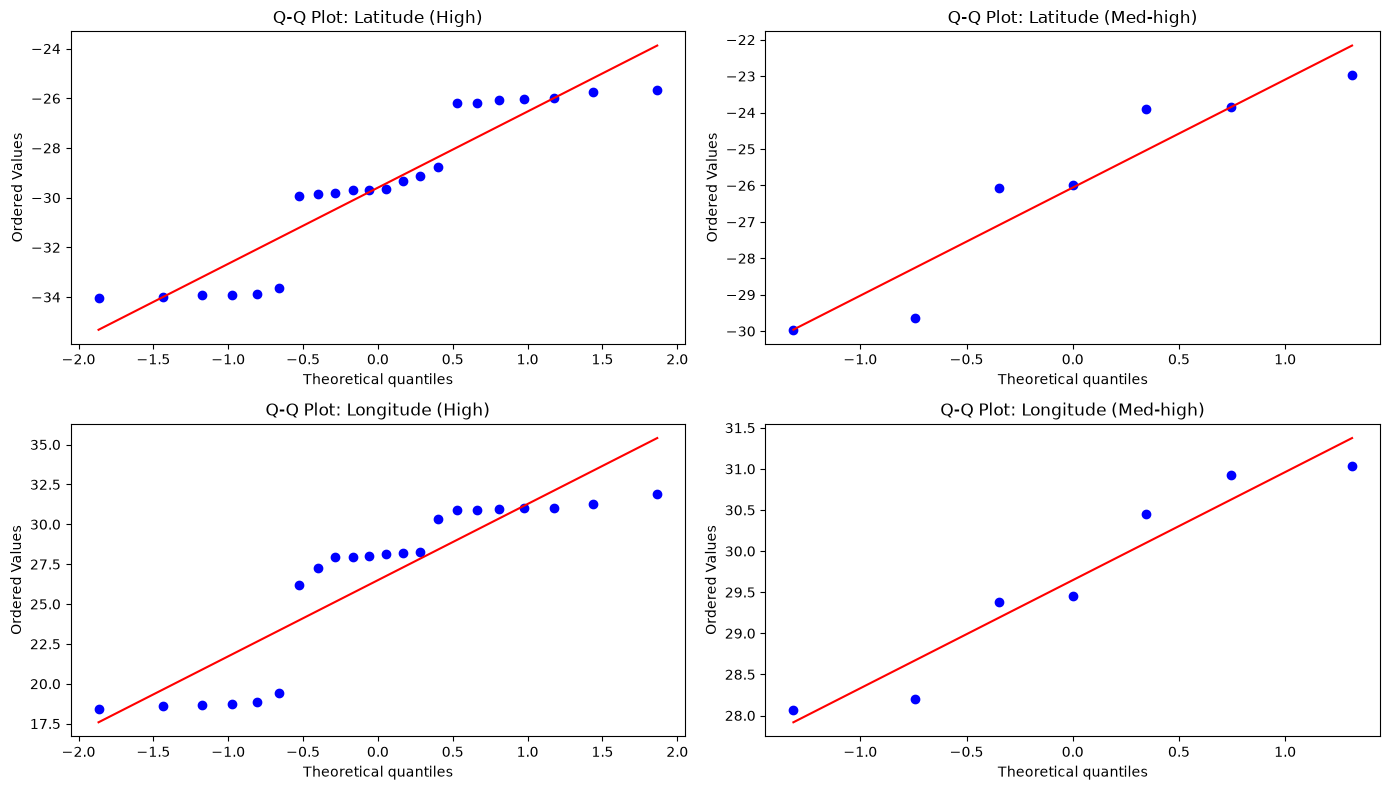

In [183]:


# Exclude SA Total row
gbv_clean = gbv[gbv["Province"].str.strip().str.lower() != "sa total"].copy()

# Ensure Latitude and Longitude are numeric
gbv_clean["Latitude"] = pd.to_numeric(gbv_clean["Latitude"], errors="coerce")
gbv_clean["Longitude"] = pd.to_numeric(gbv_clean["Longitude"], errors="coerce")

# Drop rows with missing values in these columns
gbv_clean = gbv_clean.dropna(subset=["Latitude", "Longitude"])

# Split by Risk category
risks = gbv_clean["Risk"].unique()
features = ["Latitude", "Longitude"]

fig, axes = plt.subplots(len(features), len(risks), figsize=(14, 8))

for i, feature in enumerate(features):
    for j, risk in enumerate(risks):
        ax = axes[i, j]
        subset = gbv_clean[gbv_clean["Risk"] == risk]
        stats.probplot(
            subset[feature],
            dist="norm",
            plot=ax
        )
        ax.set_title(f"Q-Q Plot: {feature} ({risk})")

plt.tight_layout()
plt.show()


# DISTRIBUTION PLOT

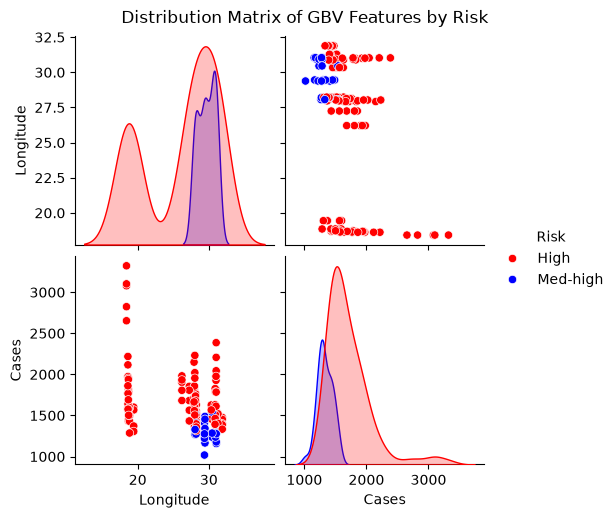

In [184]:

# Exclude SA Total row
gbv_clean = gbv[gbv["Province"].str.strip().str.lower() != "sa total"].copy()

# Reshape yearly cases into long format
gbv_long = gbv_clean.melt(
    id_vars=["Province","Risk","Latitude","Longitude"],
    value_vars=["2022","2023","2024","2025","2026"],
    var_name="Year",
    value_name="Cases"
)

# Select features for the matrix
features = ["Latitude", "Longitude", "Cases"]

# Pairplot (distribution matrix)
sns.pairplot(
    gbv_long[features + ["Risk"]],
    hue="Risk",            # stratify by risk level
    diag_kind="kde",       # KDE plots on the diagonal
    palette={"High":"red","Med-high":"blue"}
)

plt.suptitle("Distribution Matrix of GBV Features by Risk", y=1.02)
plt.show()


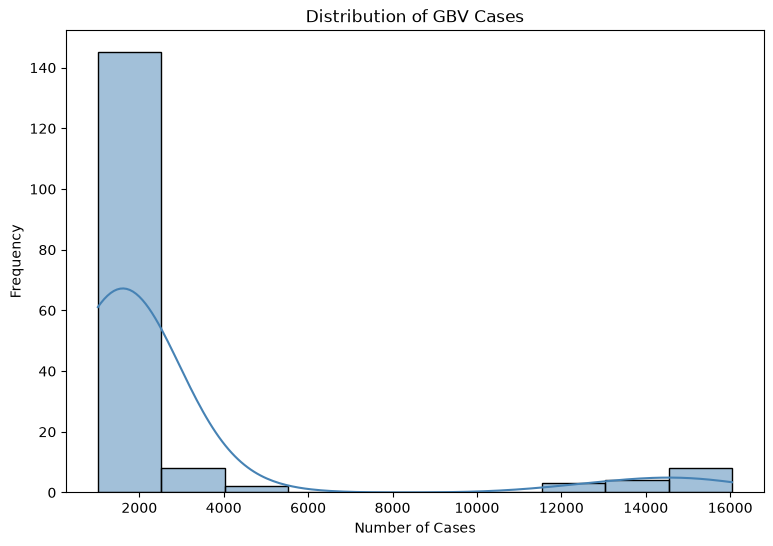

In [185]:

# Exclude SA Total row
gbv_clean = gbv[gbv["Province"].str.strip().str.lower() != "sa total"].copy()

# Reshape yearly cases into long format
gbv_long = gbv_clean.melt(
    id_vars=["Province","Risk","Latitude","Longitude"],
    value_vars=["2022","2023","2024","2025","2026"],
    var_name="Year",
    value_name="Cases"
)

# Plot distribution of Cases
plt.figure(figsize=(9, 6))
sns.histplot(
    data=gbv_long,
    x="Cases",
    kde=True,
    bins=10,
    color="steelblue"
)
plt.title("Distribution of GBV Cases")
plt.xlabel("Number of Cases")
plt.ylabel("Frequency")
plt.show()


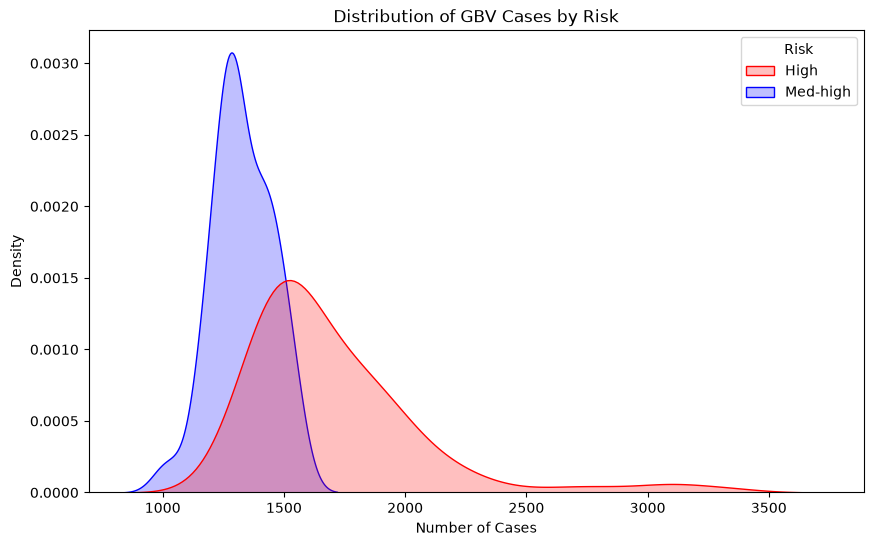

In [186]:

# Exclude SA Total row
gbv_clean = gbv[gbv["Province"].str.strip().str.lower() != "sa total"].copy()

# Reshape yearly cases into long format
gbv_long = gbv_clean.melt(
    id_vars=["Province","Risk","Latitude","Longitude"],
    value_vars=["2022","2023","2024","2025","2026"],
    var_name="Year",
    value_name="Cases"
)

# KDE plot of Cases by Risk
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=gbv_long,
    x="Cases",
    hue="Risk",
    fill=True,
    common_norm=False,
    palette={"High":"red","Med-high":"blue"}
)

plt.title("Distribution of GBV Cases by Risk")
plt.xlabel("Number of Cases")
plt.ylabel("Density")
plt.show()


# BOXPLOT 

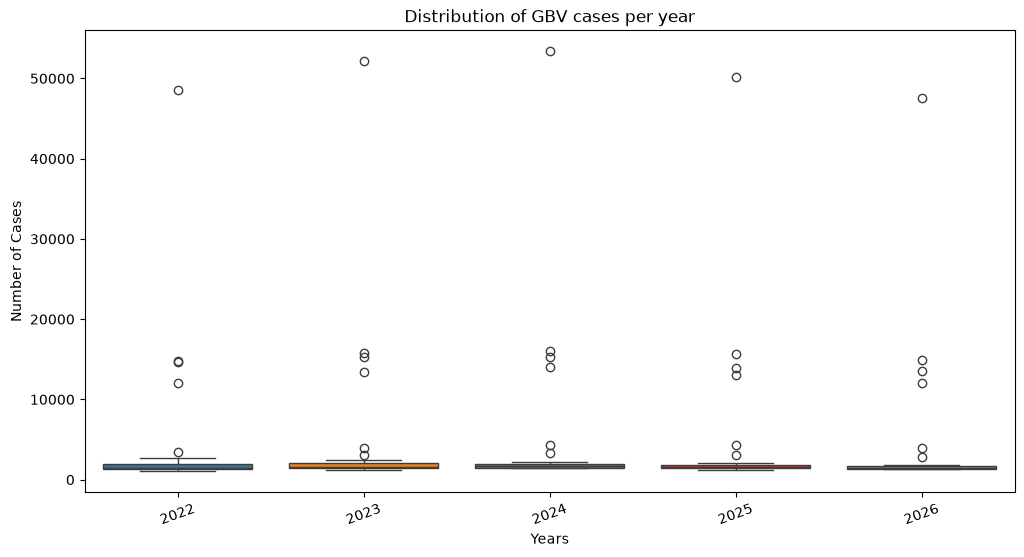

In [187]:


# Select the yearly columns
features = ["2022", "2023", "2024", "2025", "2026"]

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[features])
plt.title("Distribution of GBV cases per year")
plt.xlabel("Years")
plt.ylabel("Number of Cases")
plt.xticks(rotation=20)
plt.show()


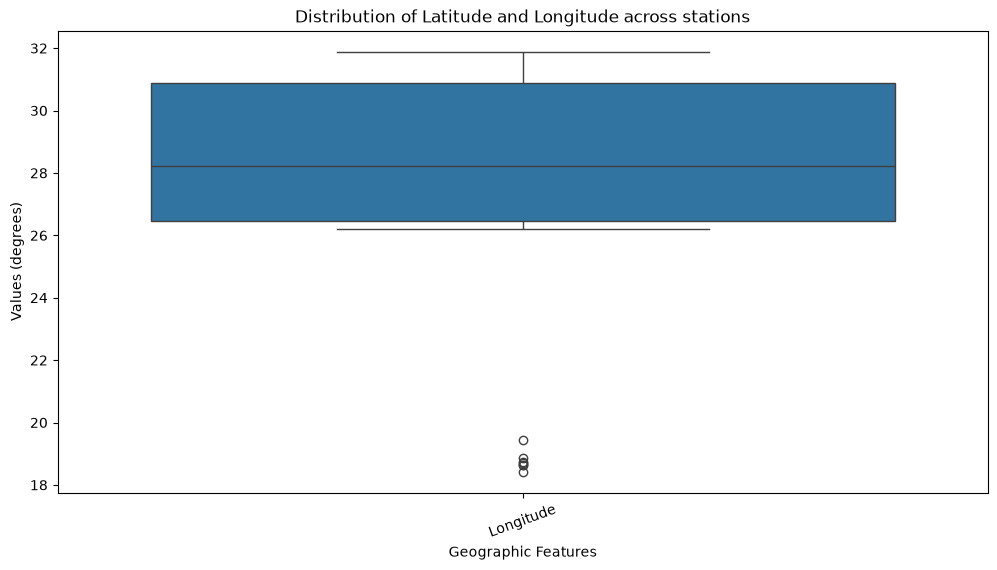

In [188]:

# Select latitude and longitude as features
features = ["Latitude", "Longitude"]

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[features])
plt.title("Distribution of Latitude and Longitude across stations")
plt.xlabel("Geographic Features")
plt.ylabel("Values (degrees)")
plt.xticks(rotation=20)
plt.show()


# CORRELATION MATRICS

           Latitude  Longitude      2022      2023      2024      2025  \
Latitude   1.000000  -0.141120 -0.084488 -0.135971 -0.149055 -0.029716   
Longitude -0.141120   1.000000 -0.340006 -0.395244 -0.457381 -0.401354   
2022      -0.084488  -0.340006  1.000000  0.999735  0.999494  0.999166   
2023      -0.135971  -0.395244  0.999735  1.000000  0.999868  0.999581   
2024      -0.149055  -0.457381  0.999494  0.999868  1.000000  0.999822   
2025      -0.029716  -0.401354  0.999166  0.999581  0.999822  1.000000   
2026      -0.082527  -0.382364  0.999476  0.999666  0.999760  0.999815   

               2026  
Latitude  -0.082527  
Longitude -0.382364  
2022       0.999476  
2023       0.999666  
2024       0.999760  
2025       0.999815  
2026       1.000000  


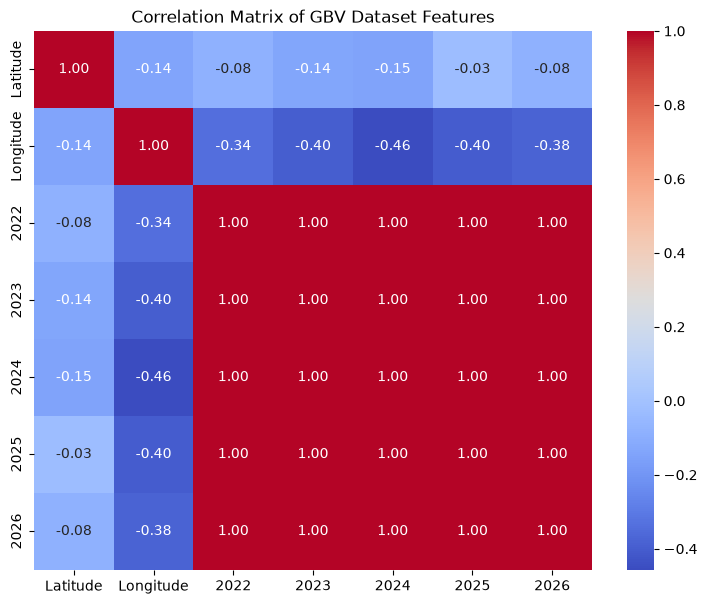

In [189]:

# Clean Latitude and Longitude columns (remove '=' and convert to float)
df["Latitude"] = df["Latitude"].astype(str).str.replace("=", "").astype(float)
df["Longitude"] = df["Longitude"].astype(str).str.replace("=", "").astype(float)

# Select numeric features
features = ["Latitude", "Longitude", "2022", "2023", "2024", "2025", "2026"]

# Compute correlation matrix
correlation = df[features].corr()

print(correlation)

# Plot heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of GBV Dataset Features")
plt.show()


# FEATURES AND TARGET

In [190]:

# Clean coordinates
df["Latitude"] = df["Latitude"].astype(str).str.replace("=", "").astype(float)
df["Longitude"] = df["Longitude"].astype(str).str.replace("=", "").astype(float)

# Fill missing risk values with "Low"
df["Risk"] = df["Risk"].fillna("Low")

# Features and target
X = df[["Latitude", "Longitude","TOTAL"]]
y = df["Risk"]


# TRAIN-TEST SPLIT

In [191]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify = y
)
print("Training features:",X_train.shape)
print("Testing features:",X_test.shape)

print("Training labels:",y_train.shape)
print("Testing labels:",y_test.shape)

Training features: (55, 3)
Testing features: (14, 3)
Training labels: (55,)
Testing labels: (14,)


# FAETURE SCALING

In [202]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Scaled sample (first 5 rows):")
print(X_scaled[:5])


Feature scaling completed.
Scaled sample (first 5 rows):
[[-0.20142342 -0.5387515  -0.49255404]
 [ 0.19375433  0.03502712 -0.51558623]
 [ 0.18411196 -0.02721873 -0.49971798]
 [ 0.17093532 -0.01176056 -0.51979169]
 [ 0.16721124  0.0061078  -0.49350761]]


# DEFINE MODELS

In [207]:
from sklearn.calibration import CalibratedClassifierCV

models= {
    "Logistic Regression":
        LogisticRegression(
            max_iter= 1000,
            random_state= 42
        ),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state= 42
        ),
    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
    "Support Vector Machine":
        CalibratedClassifierCV(
        SVC(kernel="rbf", random_state=42),
        ensemble=False
    ),
    "Gaussian Naive Bayes":
        GaussianNB(),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),
    "MLP Neural Network":
        MLPClassifier(
            hidden_layer_sizes=(100,),
            max_iter=2000,
            random_state=42
        )
}


# TRAIN MODELS

In [208]:

trained_models = {}
for name, model in models.items():
    print("Training:", name)

    model.fit(
        X_train_scaled,
        y_train
    )
    trained_models[name] = model

print("\nAll models succesfully trained.")


Training: Logistic Regression
Training: K-Nearest Neighbours
Training: Decision Tree
Training: Random Forest
Training: Support Vector Machine
Training: Gaussian Naive Bayes
Training: Gradient Boosting
Training: MLP Neural Network

All models succesfully trained.


# MODEL PREDICTIONS

In [210]:
predictions= {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    print("\n", name)
    print(y_pred)


 Logistic Regression
['Low' 'Med-high' 'Low' 'Low' 'High' 'Low' 'Med-high' 'High' 'Med-high'
 'Med-high' 'Low' 'Med-high' 'High' 'Med-high']

 K-Nearest Neighbours
['Low' 'Med-high' 'Low' 'Low' 'Med-high' 'Low' 'Med-high' 'Med-high'
 'Med-high' 'Med-high' 'Low' 'Med-high' 'Med-high' 'Med-high']

 Decision Tree
['Low' 'Med-high' 'Low' 'Low' 'Med-high' 'Low' 'High' 'Med-high'
 'Med-high' 'Med-high' 'Low' 'Med-high' 'High' 'High']

 Random Forest
['Low' 'Med-high' 'Low' 'Low' 'Med-high' 'Low' 'High' 'Med-high'
 'Med-high' 'Med-high' 'Low' 'Med-high' 'High' 'High']

 Support Vector Machine
['Low' 'Med-high' 'Low' 'Low' 'Med-high' 'Low' 'Med-high' 'Med-high'
 'Med-high' 'Med-high' 'Low' 'Med-high' 'Med-high' 'Med-high']

 Gaussian Naive Bayes
['Low' 'Med-high' 'Low' 'Low' 'Med-high' 'Low' 'High' 'Med-high'
 'Med-high' 'Med-high' 'Low' 'Med-high' 'Med-high' 'High']

 Gradient Boosting
['Low' 'Med-high' 'Low' 'Low' 'Med-high' 'Low' 'High' 'Med-high'
 'Med-high' 'Med-high' 'Low' 'Med-high' 'H

# ACCURACY OF THE MODELS

In [211]:
for name, y_pred in predictions.items():

    accuracy = accuracy_score(
        y_test,
        y_pred
    )
    print(
        f"{name}: {accuracy:.4f}"
    )


Logistic Regression: 0.6429
K-Nearest Neighbours: 0.7143
Decision Tree: 0.9286
Random Forest: 0.9286
Support Vector Machine: 0.7143
Gaussian Naive Bayes: 0.8571
Gradient Boosting: 0.9286
MLP Neural Network: 0.7143


# PERFORMANCE MATRICS

In [216]:

results = []

for name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append([name, accuracy, precision, recall, f1])

# ✅ Build DataFrame after the loop
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

print(results_df)


                    Model  Accuracy  Precision    Recall  F1 Score
0     Logistic Regression  0.642857   0.630952  0.642857  0.633581
1    K-Nearest Neighbours  0.714286   0.555556  0.714286  0.612245
2           Decision Tree  0.928571   0.940476  0.928571  0.926716
3           Random Forest  0.928571   0.940476  0.928571  0.926716
4  Support Vector Machine  0.714286   0.555556  0.714286  0.612245
5    Gaussian Naive Bayes  0.857143   0.897959  0.857143  0.845238
6       Gradient Boosting  0.928571   0.940476  0.928571  0.926716
7      MLP Neural Network  0.714286   0.714286  0.714286  0.714286


# MODELS COMPARISONS BAR GRAPH

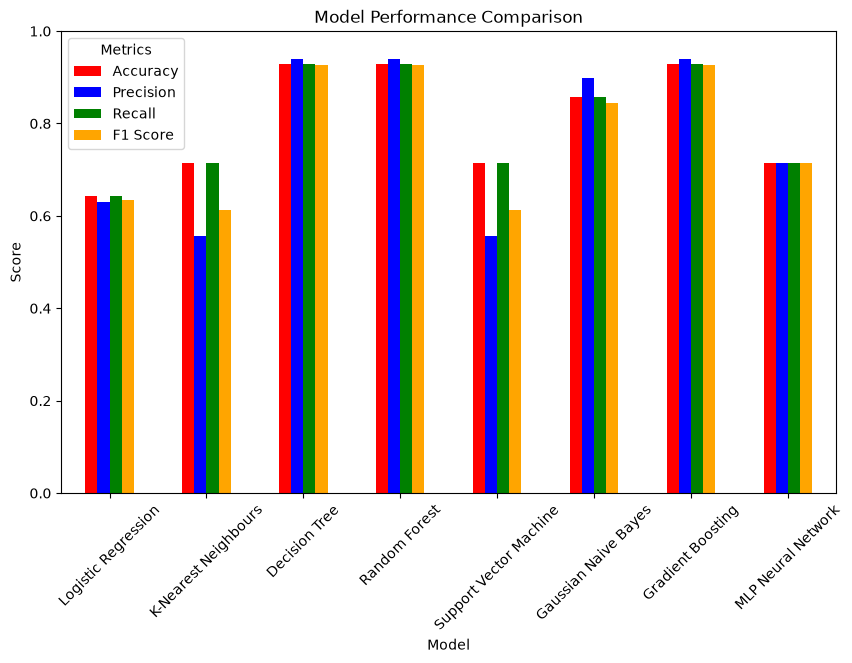

In [217]:

# Define colors for each model
colors = ["red", "blue", "green", "orange", "purple"]

# Plot grouped bar chart for all metrics
results_df.plot(
    x="Model",
    kind="bar",
    figsize=(10,6),
    color=colors
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0,1)  # metrics are between 0 and 1
plt.legend(title="Metrics")
plt.show()
